# 한국 대학 학과 진화: 통계물리–정보이론 temporal analysis

이 노트북은 Bachmann et al.의 size-dependent organizational ecology와 Becker–Döring 관점을
한국 대학 학과 Alluvial 계보에 확장한다.

핵심 질문은 다음과 같다.

> 현재 학과 규모, 대학 환경, 최근 개명과 명칭 수식어가 다음 해의 유지·폐지·통합·분리에 관해 각각 몇 bit의 정보를 제공하는가?

분석의 세 층은 다음과 같다.

1. **Local size dynamics:** `s → s±Δs`, stable range, Becker–Döring drift.
2. **Organizational events:** continue, close, merge, split, complex; birth는 별도 집계.
3. **Predictive information:** entropy, CMI, entropy rate, lagged/TE-like information, out-of-time information gain.

연속성은 `alluvial/*.json`의 DAG를 기준으로 하며, 교원 자료는 노드의 `faculty_size` 속성으로만 결합한다.
Alluvial의 `msz`(묶인 전공 수)와 전임교원 수를 혼동하지 않는다.

Sources: [Bachmann et al. (2026)](https://arxiv.org/abs/2607.22189),
[Shannon (1948)](https://people.math.harvard.edu/~ctm/home/text/others/shannon/entropy/entropy.pdf),
[Schreiber (2000)](https://doi.org/10.1103/PhysRevLett.85.461).

## 0. 실행 조건과 재현성

원자료 Excel은 공개 저장소에 넣지 않는다. 실행 전에 환경변수 `FACULTY_DATA_DIR`를
「6-가-1 전체 교원 대비 전임교원 현황」 파일 폴더로 지정한다.

```bash
export FACULTY_DATA_DIR="/path/to/대학알리미 데이터"
```

환경변수가 없으면 macOS Google Drive의 일반적인 위치를 자동 탐색한다.
산출물은 `analysis/figures`와 `analysis/tables`에 저장된다.

In [1]:
import os, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "alluvial").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

faculty_env = os.environ.get("FACULTY_DATA_DIR")
if faculty_env:
    FACULTY_DIR = Path(faculty_env)
else:
    candidates = list(Path.home().glob(
        "Library/CloudStorage/GoogleDrive-*/내 드라이브/how large academy/대학알리미 데이터"
    ))
    if not candidates:
        raise FileNotFoundError("Set FACULTY_DATA_DIR to the faculty workbook directory.")
    FACULTY_DIR = candidates[0]

FIG_DIR = REPO_ROOT / "analysis" / "figures"
TABLE_DIR = REPO_ROOT / "analysis" / "tables"
print("repository ready:", REPO_ROOT.exists())
print("faculty files found:", len(list(FACULTY_DIR.glob("*.xlsx"))))

repository ready: True
faculty files found: 42


## 1. Alluvial-first panel 생성

예측 관측단위는 연도 `t`의 source node다. 한 node가 여러 후속 node를 가지면 split,
후속 node가 여러 predecessor를 가지면 merge다. `complex`는 many-to-many 재편이다.

교원 수 결합은 다음 순서를 따른다.

1. 이름 있는 캠퍼스를 보존한 학교 ID
2. 학교–연도–학과 exact match
3. 학부 노드의 `members` 교원 수 합산
4. 유일한 정규화명 match

불확실한 부분 match는 본 분석 표본에서 제외한다.

In [2]:
from analysis.info_theory_pipeline import run_analysis

bundle = run_analysis(
    REPO_ROOT,
    FACULTY_DIR,
    figure_dir=FIG_DIR,
    table_dir=TABLE_DIR,
    n_perm=200,
)
pd.Series({k: v for k, v in bundle.summary.items() if not isinstance(v, pd.DataFrame)}, name="value")

n_alluvial_nodes_2015_2025        93703
n_analysis_rows                   65979
size_match_rate_all_nodes      0.835918
size_full_member_match_rate    0.825203
event_entropy_bits             0.294897
restructure_rate               0.043862
rename_rate_among_continue     0.051106
markov_entropy_rate_bits       0.561341
bd_fit                              SLL
bd_s_star                             4
Name: value, dtype: object

In [3]:
audit = pd.DataFrame({
    "quantity": [
        "Alluvial nodes, 2015–2025",
        "nodes with any faculty-size match",
        "nodes with complete member match",
        "analysis source-node rows",
        "restructure rate",
        "rename rate among continuations",
    ],
    "value": [
        bundle.summary["n_alluvial_nodes_2015_2025"],
        bundle.summary["size_match_rate_all_nodes"],
        bundle.summary["size_full_member_match_rate"],
        bundle.summary["n_analysis_rows"],
        bundle.summary["restructure_rate"],
        bundle.summary["rename_rate_among_continue"],
    ],
})
audit

,quantity,value
0,"Alluvial nodes, 2015–2025",93703.000000
1,nodes with any faculty-size match,0.835918
2,nodes with complete member match,0.825203
3,analysis source-node rows,65979.000000
4,restructure rate,0.043862
5,rename rate among continuations,0.051106


## 2. Temporal event decomposition

원 논문의 `closure: s>0 → 0`에는 실제 폐지, merge, split, rename이 섞일 수 있다.
여기서는 Alluvial degree를 이용해 이를 분해한다.

Birth는 기존 학과의 fate와 위험집합이 다르므로 count로 별도 표시한다. 본격적인 birth 예측에는
`(university, subfield, year)` absent-cell risk table이 필요하다.

event_next,year,continue,close,merge,split,complex,rename,birth_count
0,2015,0.96634,0.02517,0.00776,0.00073,0.0,0.04437,579
1,2016,0.91923,0.06279,0.01680,0.00118,0.0,0.06862,417
2,2017,0.96302,0.02985,0.00667,0.00045,0.0,0.05869,661
3,2018,0.98290,0.01496,0.00137,0.00076,0.0,0.03292,333
4,2019,0.96940,0.02558,0.00411,0.00091,0.0,0.03675,236
5,2020,0.96020,0.03169,0.00612,0.00199,0.0,0.04145,337
6,2021,0.95053,0.03718,0.01002,0.00228,0.0,0.05476,505
7,2022,0.94610,0.04793,0.00322,0.00276,0.0,0.05697,425
8,2023,0.95527,0.03854,0.00464,0.00155,0.0,0.06124,492
9,2024,0.94913,0.04596,0.00306,0.00184,0.0,0.05666,690


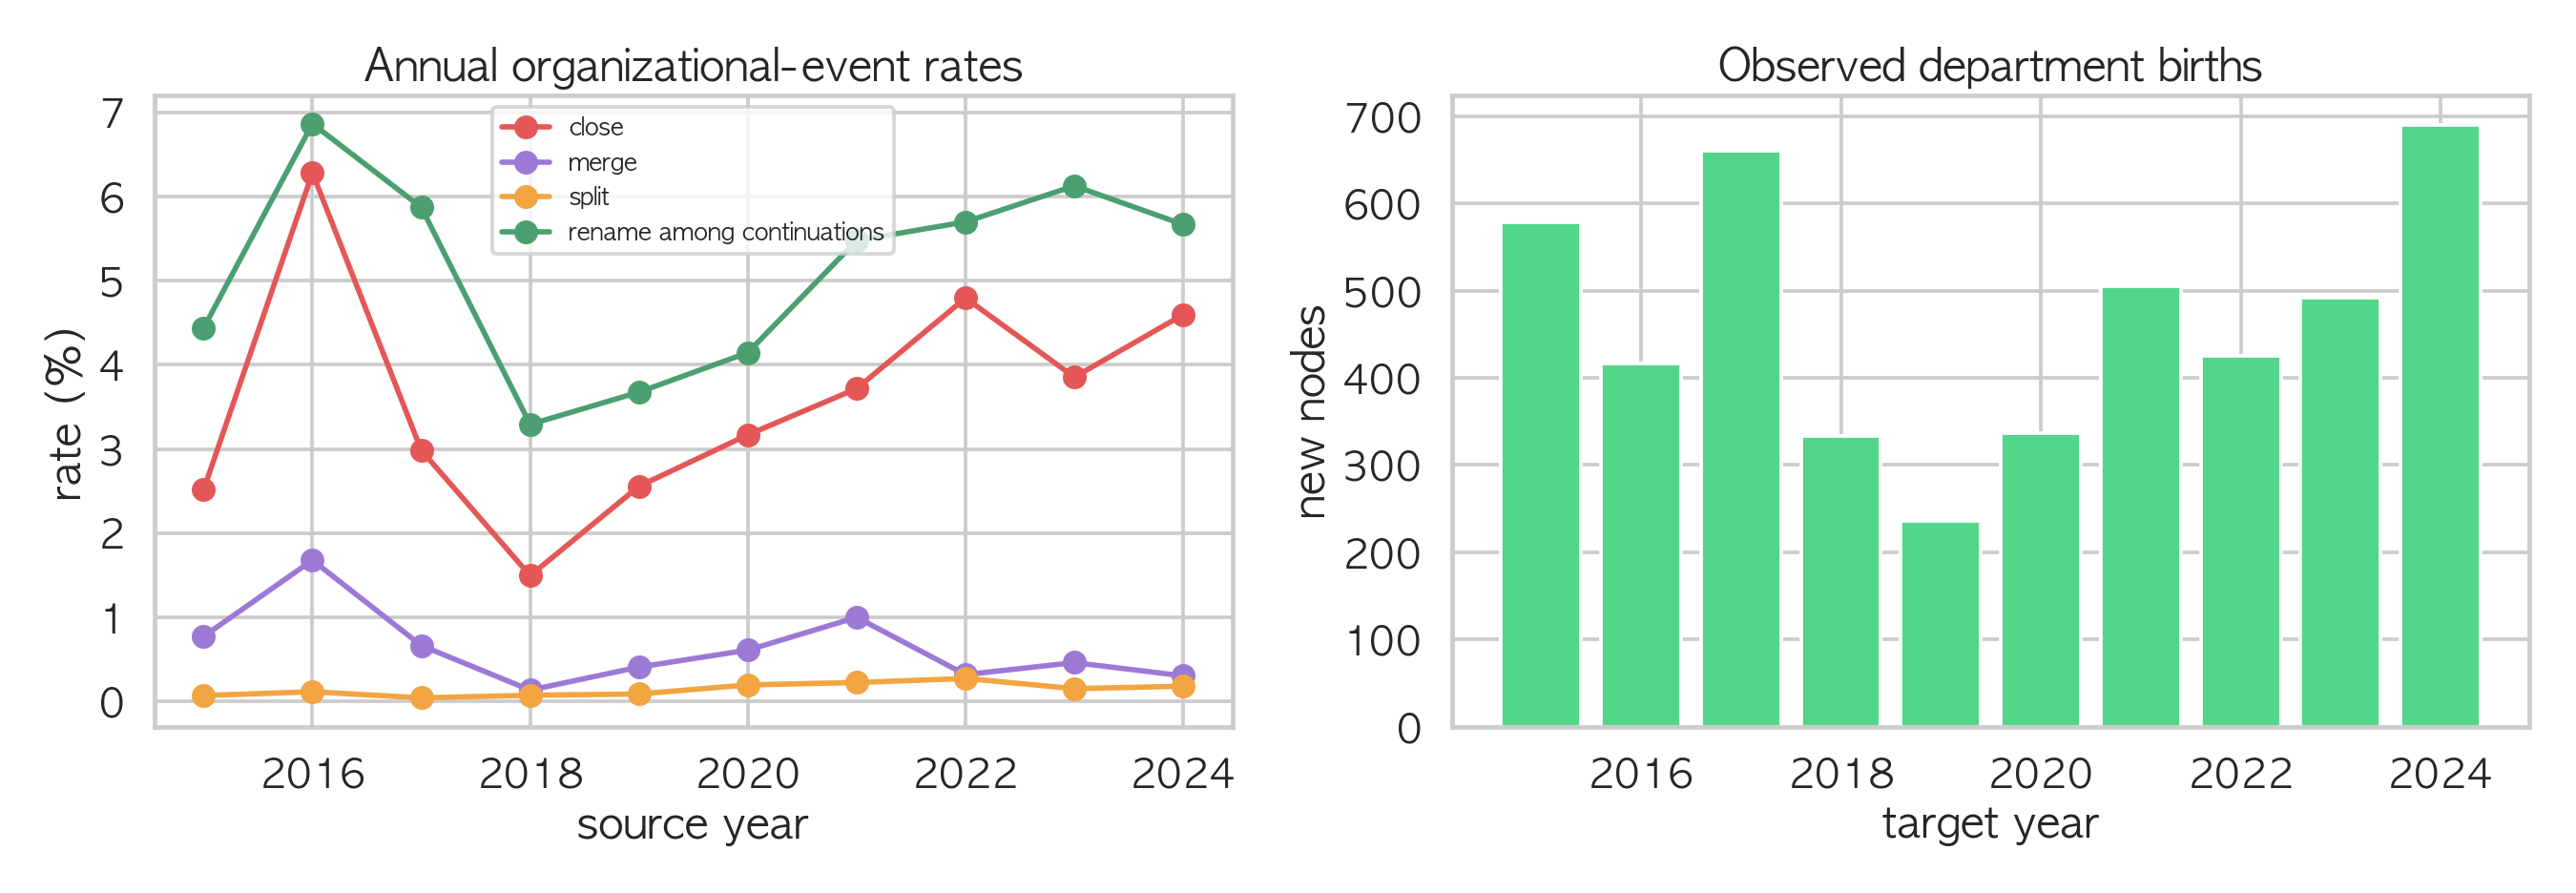

In [4]:
display(bundle.temporal.round(5))
display(Image(filename=str(FIG_DIR / "fig01_temporal_events.png")))

## 3. 규모 의존 조직생태학

분야별 대표규모 분포에서 empirical mode `s*_f`와 한 geometric standard deviation 범위를 구한다.
아래 그래프는 `s/s*_f`에 따른 구조사건 확률을 보여준다.

규모가 사건에 주는 정보는

\[
I(S_t;E_{t+1}\mid F,T)
=H(E_{t+1}\mid F,T)-H(E_{t+1}\mid S_t,F,T)
\]

로 측정한다. 이는 size effect의 인과효과가 아니라 분야·연도를 조건화한 **잔여 예측정보**다.

,broad,n_segments,median,s_minus,s_plus,s_star
0,공학,3011,7.000,3.190,15.363,6.0
1,예체능,1603,4.000,2.084,7.676,4.0
2,의학,72,120.499,38.580,376.359,24.0
3,인문사회,4242,5.000,2.452,10.196,5.0
4,자연과학,2071,6.000,2.967,12.133,5.0


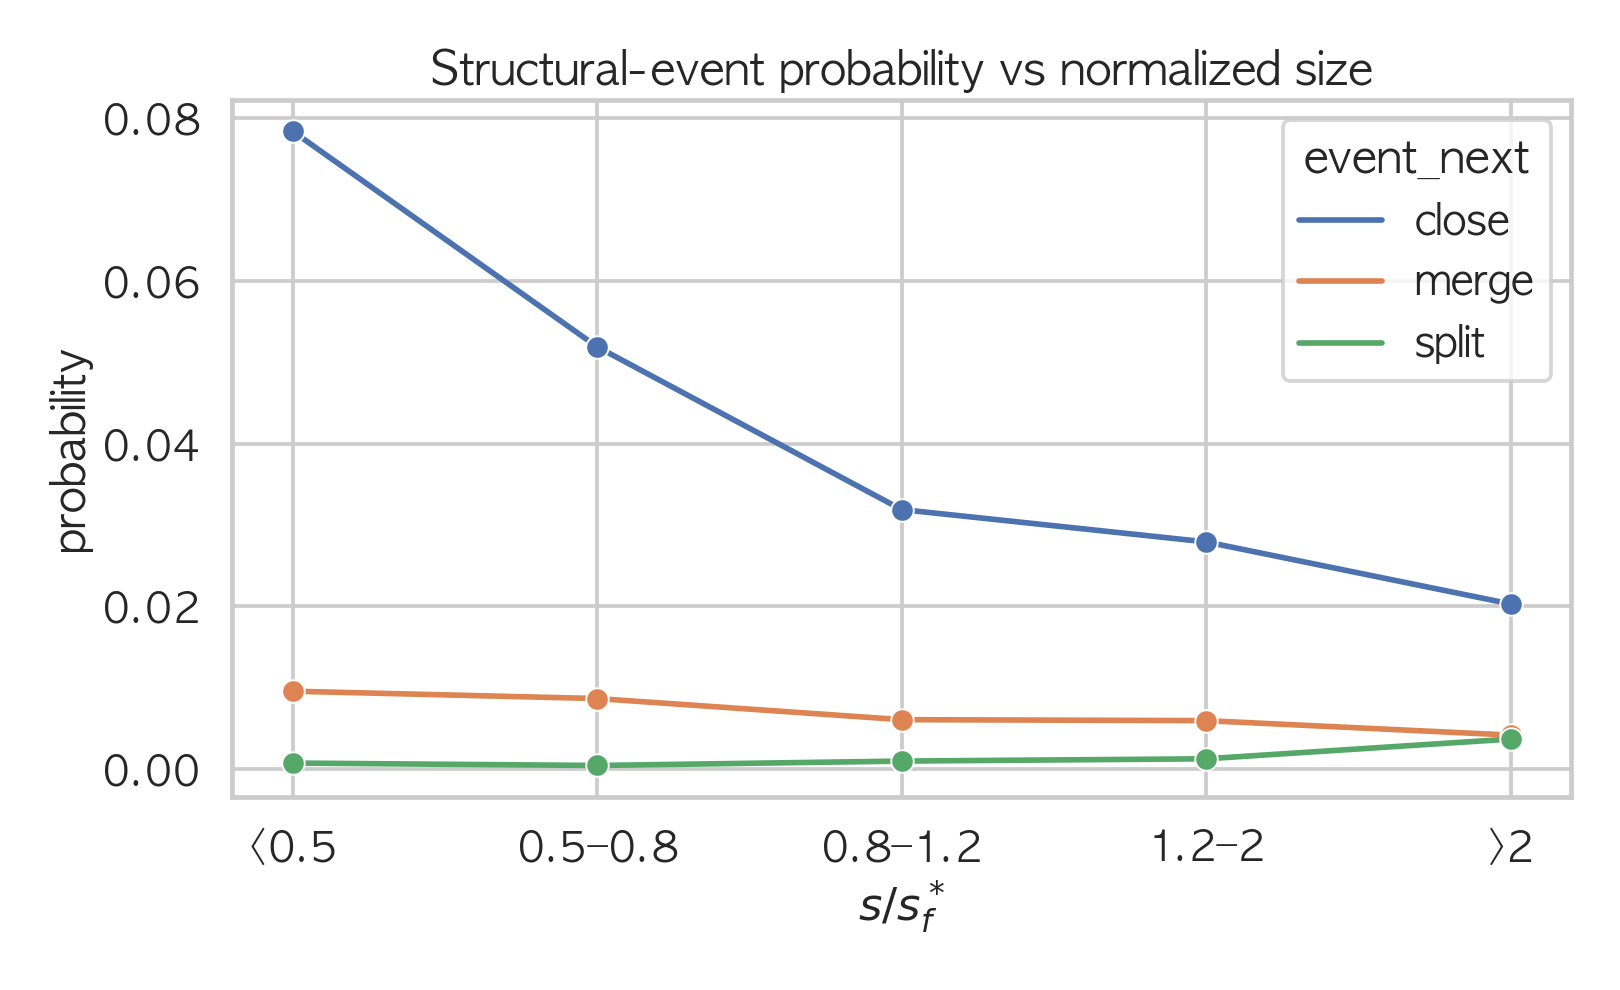

In [5]:
display(bundle.stable_ranges.round(3))
display(Image(filename=str(FIG_DIR / "fig02_event_hazard_size.png")))

## 4. Entropy, CMI와 TE-like lagged information

- `H(event)`: 아무 feature가 없을 때 next event의 불확실성.
- `I(size regime; event | field, year)`: 원 논문의 size dependence를 bit로 요약.
- `I(previous rename; restructure | size, field, year)`: 직전 개명이 다음 구조재편에 주는 추가정보.
- `I(school change; restructure | focal state)`: 대학 전체 수축/팽창의 lagged directed predictive information.

마지막 값은 한 시차 CMI이므로 `TE-like`라고 부른다. 11개 연도로 continuous transfer entropy를
과도하게 추정하지 않는다. 모든 값은 구조를 보존한 block permutation null과 비교한다.

In [6]:
bundle.info_table.round(6)

,measure,bits,null_mean,bias_corrected_bits,z_score,p_perm
0,H(event),0.294897,NaN,NaN,NaN,NaN
1,"I(size regime; event | field, year)",0.007061,0.002451,0.004610,20.700060,0.004975
2,"I(previous rename; restructure | size, field, ...",0.002543,0.001239,0.001304,9.512582,0.004975
3,TE-like I(school change; restructure | focal s...,0.007156,0.004620,0.002536,8.971072,0.004975


## 5. Out-of-time predictive information gain

Rolling-origin validation에서 다음 모형을 순차 비교한다.

- M0: field + time
- M1: M0 + current size
- M2: M1 + size history, age, university/neighbor context
- M3: M2 + previous rename, added modifiers, name novelty, thematic-entropy proxy

두 모형의 확률 예측 차이는

\[
\widehat I(X;Y\mid Z)
=\frac{1}{N}\sum_i\log_2
\frac{\hat p_{full}(y_i\mid x_i,z_i)}{\hat p_{base}(y_i\mid z_i)}
\]

로 계산한다. Error bar는 university-cluster bootstrap 95% interval이다.
희소한 merge/split multiclass 확률은 training-fold empirical prior와 10% shrinkage하여
극단적인 zero-probability 예측을 막고, empirical-prior baseline과 직접 비교한다.

,model,n_test,log_loss_bits,brier,roc_auc,pr_auc
0,M0 field+time,39210.0,0.266735,0.042958,0.547496,0.050580
1,M1 + size,39210.0,0.262535,0.042705,0.611927,0.067530
2,M2 + context,39210.0,0.258773,0.042701,0.670950,0.082380
3,M3 + name history,39210.0,0.256100,0.042540,0.684960,0.086612


,feature_block,incremental_bits_per_event,ci_low,ci_high
0,size,0.004200,0.002320,0.006693
1,context,0.003762,-0.000369,0.007646
2,name history,0.002674,0.001404,0.003912


,model,n_test,log_loss_bits,macro_f1,balanced_accuracy
0,empirical-prior,39210.0,0.299726,0.244256,0.25
1,full,39210.0,0.287100,0.244256,0.25
2,size-only,39210.0,0.294583,0.244256,0.25


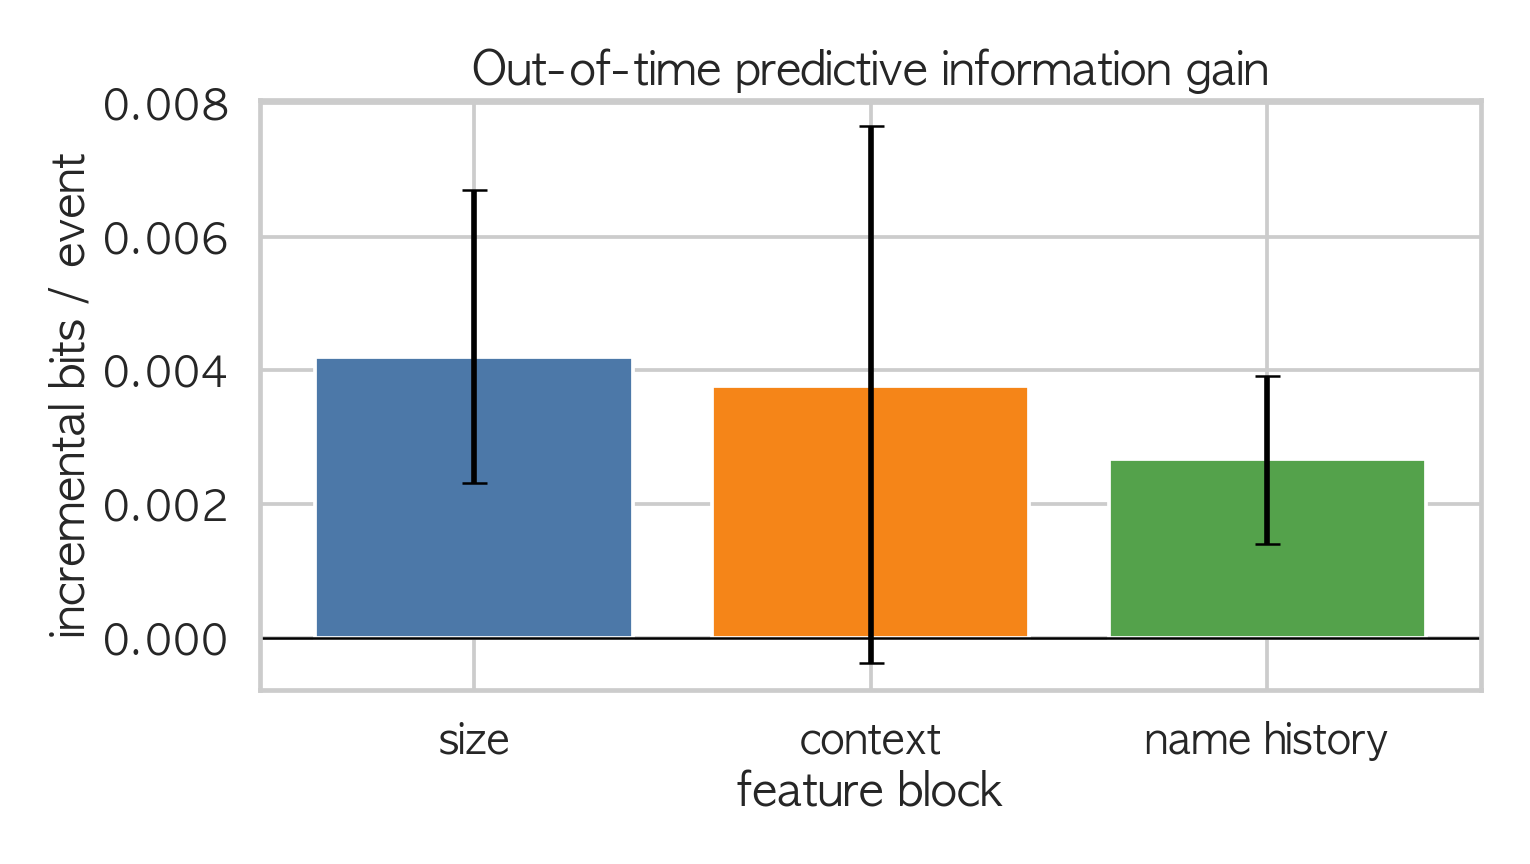

In [7]:
display(bundle.summary["binary_performance"].round(6))
display(bundle.predictive_table.round(6))
display(bundle.multiclass_table.round(6))
display(Image(filename=str(FIG_DIR / "fig03_predictive_information.png")))

## 6. 이름변경과 수식어 추가의 temporal signal

개명은 continuity를 끊지 않지만 정보는 버리지 않는다.

- `rename_next`: 동일 계보에서 표시명이 바뀌었는가?
- `added_modifiers_next`: 후속 명칭에 새로 나타난 명사 토큰
- `previous rename`: `t-1 → t` 개명 여부; `t+1` 예측에만 사용
- `name novelty`: 해당 연도까지의 과거 명칭 빈도에 대한 surprisal
- `theme entropy proxy`: 학부 `members` 명칭의 keyword entropy

`t → t+1`에 추가된 수식어를 같은 전이의 사건 예측 feature로 쓰면 leakage다. 따라서 동시 변화는
temporal outcome으로 기술하고, 예측에서는 직전 전이까지만 사용한다.

,year,modifier,count,share
0,2016,경영,11,0.211538
1,2016,경영학,8,0.153846
4,2016,문화,7,0.134615
5,2016,미디어,7,0.134615
9,2016,행정학,6,0.115385
7,2016,융합,5,0.096154
6,2016,산업,3,0.057692
2,2016,공학,2,0.038462
3,2016,글로벌,2,0.038462
8,2016,행정,1,0.019231


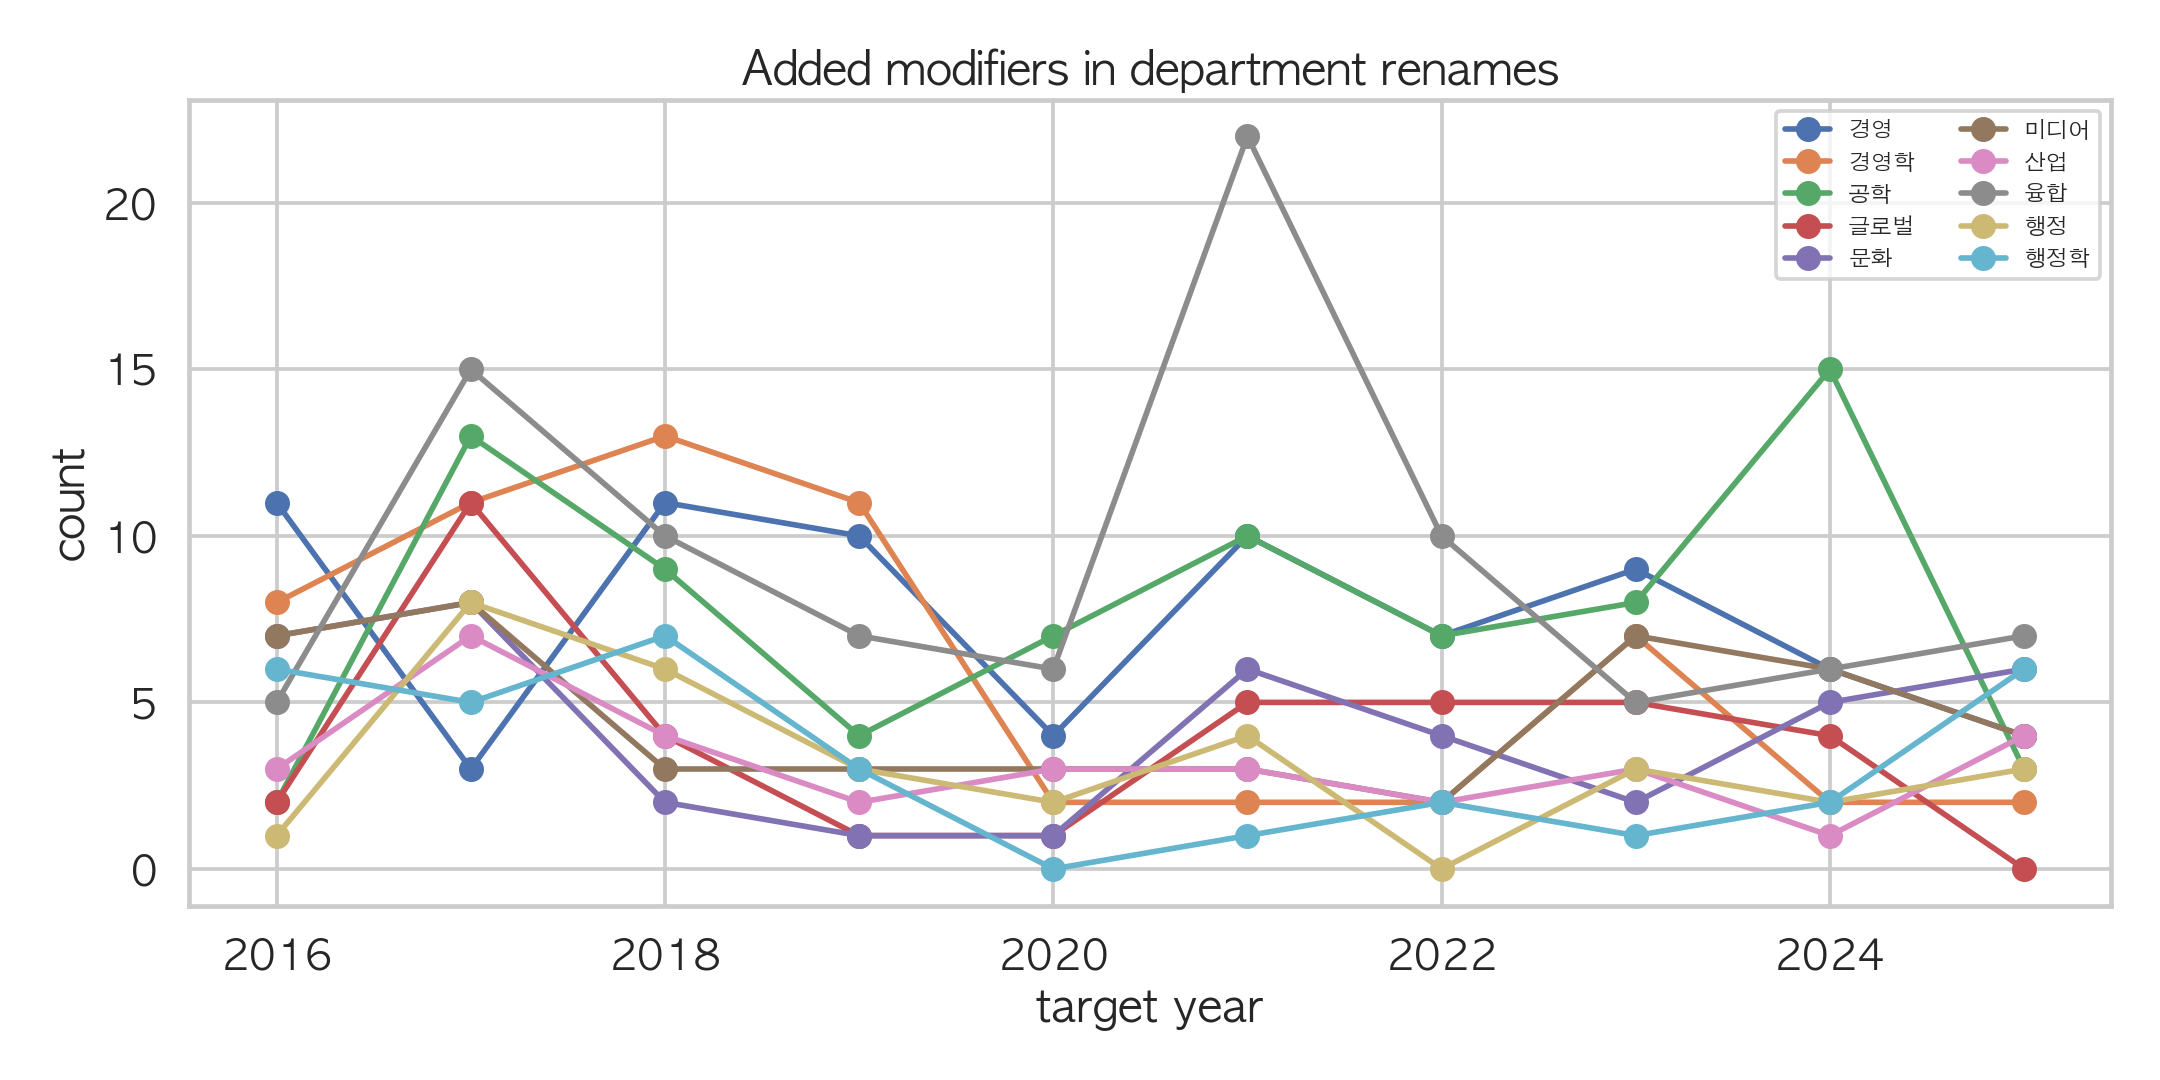

In [8]:
display(bundle.modifier_table.sort_values(["year", "count"], ascending=[True, False]).head(40))
display(Image(filename=str(FIG_DIR / "fig05_added_modifiers.png")))

## 7. Markov state와 entropy rate

규모 상태를 `small/stable/large`로 나누고 closure를 `absent` 전이로 둔다.

\[
T_{ab}=P(S_{t+1}=b\mid S_t=a),\qquad
h_1=H(S_{t+1}\mid S_t).
\]

split은 각 successor에 `1/outdegree` weight를 주어 source mass를 보존한다. 이 행렬은 조직 사건의
관계구조 전체를 대체하지 않으며, event-conditioned tensor의 1차 요약이다.

target,small,stable,large,absent
source,,,,
small,0.7196,0.1938,0.0051,0.0814
stable,0.0193,0.9264,0.0183,0.0360
large,0.0017,0.0911,0.8884,0.0188


First-order Markov entropy-rate approximation: 0.5613 bits/year


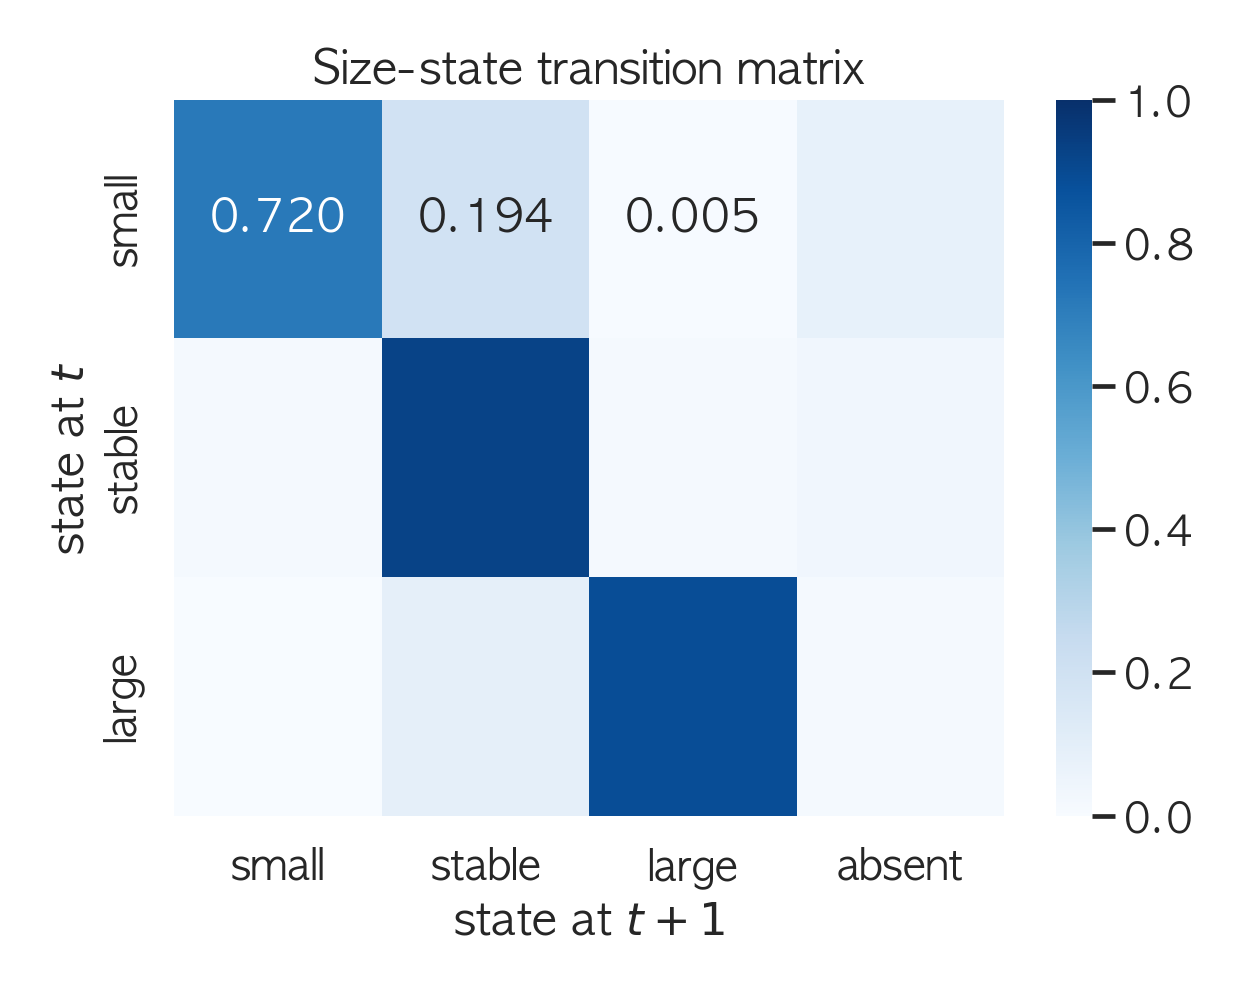

In [9]:
display(bundle.transition_matrix.round(4))
print("First-order Markov entropy-rate approximation:", round(bundle.summary["markov_entropy_rate_bits"], 4), "bits/year")
display(Image(filename=str(FIG_DIR / "fig04_transition_matrix.png")))

## 8. Becker–Döring local dynamics와 실제 구조사건

원 논문의 local process는

\[
D_s+F\rightleftharpoons D_{s+1}
\]

이다. 한국 계보에서는 이를 실제 조직반응과 분리한다.

\[
D_s\to\varnothing,\quad
D_s+D_r\to D_u,\quad
D_s\to D_r+D_u.
\]

왼쪽은 대표규모 분포에서 얻은 정규화된 `q_{s+1}/q_s`, 오른쪽은 실제 continue-only 평균 drift다.
정적 분포에서 도출한 방향과 동적 drift가 같은지는 model check이지, detailed balance의 증명은 아니다.

selected static fit: SLL | fitted mode: 4


,s,bd_ratio,fit,s_star,mean,count
0,1,2.7484,SLL,4,0.6861,1507
1,2,1.5244,SLL,4,0.4932,2423
2,3,1.1645,SLL,4,0.2134,4699
3,4,1.0000,SLL,4,0.0925,8128
4,5,0.9175,SLL,4,0.0094,9643
5,6,0.8767,SLL,4,-0.0390,8034
6,7,0.8588,SLL,4,-0.1121,5755
7,8,0.8534,SLL,4,-0.1078,4082
8,9,0.8551,SLL,4,-0.0846,2874
9,10,0.8606,SLL,4,-0.1477,2349


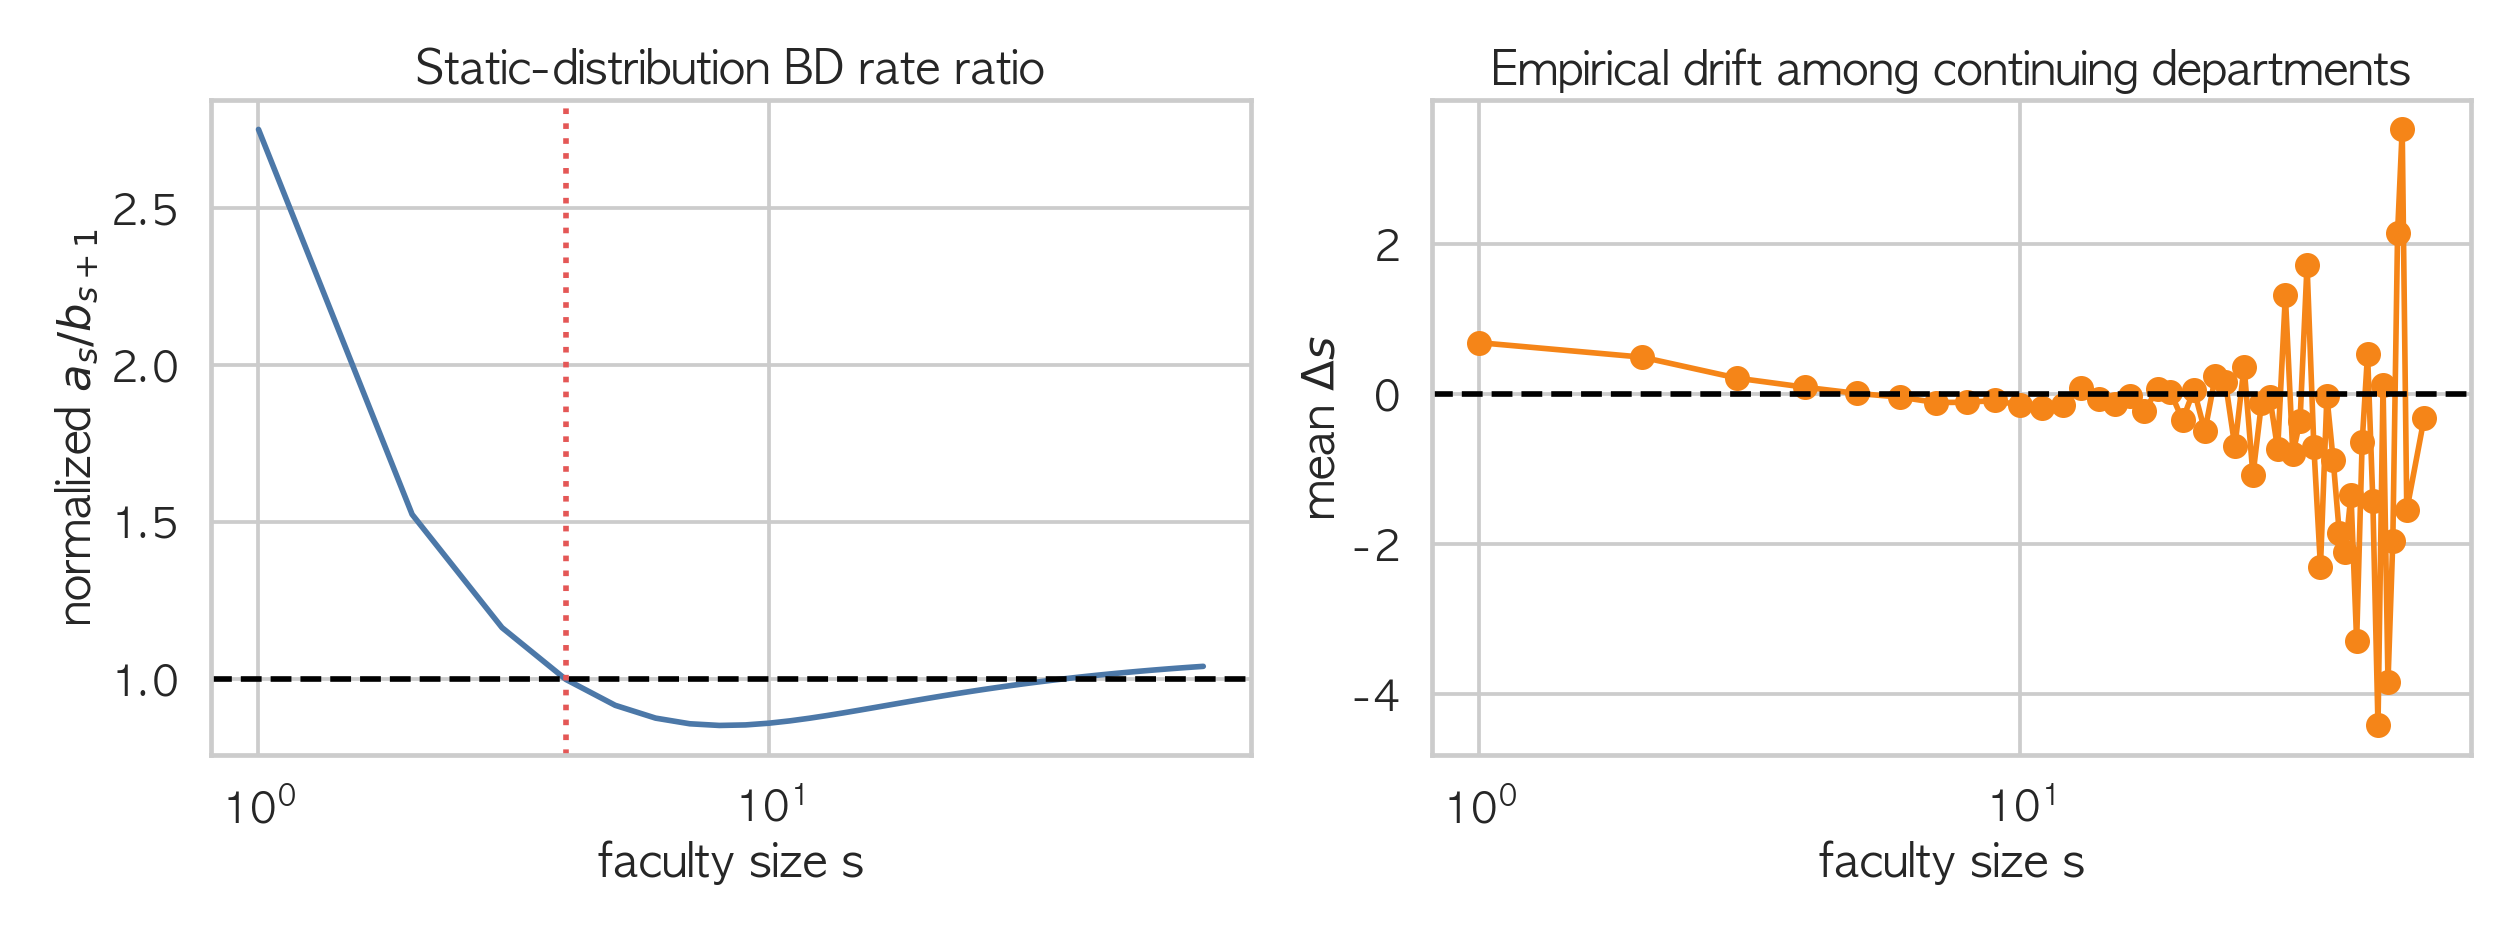

In [10]:
print("selected static fit:", bundle.summary["bd_fit"], "| fitted mode:", bundle.summary["bd_s_star"])
display(bundle.bd_table.head(20).round(4))
display(Image(filename=str(FIG_DIR / "fig06_bd_and_empirical_drift.png")))

## 9. 자동 Results 해석

다음 셀은 실행된 수치만 사용해 report할 수 있는 결과와 아직 주장할 수 없는 부분을 분리한다.

In [11]:
info = bundle.info_table.set_index("measure")
pred = bundle.predictive_table.set_index("feature_block")
size_cmi = info.loc["I(size regime; event | field, year)", "bias_corrected_bits"]
rename_cmi = info.loc["I(previous rename; restructure | size, field, year)", "bias_corrected_bits"]
te_like = info.loc["TE-like I(school change; restructure | focal state)", "bias_corrected_bits"]

report = f'''
### Empirical results

- 분석표본은 **{bundle.summary['n_analysis_rows']:,} department-year source nodes**이고,
  완전한 member-level 교원수 결합률은 **{bundle.summary['size_full_member_match_rate']:.1%}**다.
- next-event entropy는 **{bundle.summary['event_entropy_bits']:.4f} bits**다. 낮은 값의 주원인은
  continue class의 압도적 빈도이며, 이것만으로 사건이 잘 예측된다는 뜻은 아니다.
- field와 year를 조건화한 size-regime의 bias-corrected CMI는
  **{size_cmi:.5f} bits/event**다. 한국 자료에서도 size-dependent organizational ecology와
  일치하는 잔여 예측정보가 존재한다.
- 직전 개명은 현재 규모·분야·연도를 알고도 다음 구조재편에
  **{rename_cmi:.5f} bits/event**의 정보를 더한다. 개명/수식어 변화는 단순 노이즈로 버리면 안 된다.
- 대학 전체 학과수 변화의 TE-like 잔여정보는 **{te_like:.5f} bits/event**다. 이는 institution-level
  restructuring field와 일치하지만 인과효과는 아니다.
- out-of-time model에서 size block은 **{pred.loc['size','incremental_bits_per_event']:.5f} bits/event**,
  name-history block은 **{pred.loc['name history','incremental_bits_per_event']:.5f} bits/event**를 추가했다.

### Report-worthy claim

> Department size retains out-of-time information about organizational fate after conditioning on field and time. Recent renaming and modifier changes provide additional predictive information, indicating that Korean department evolution is information-structured beyond size alone.

### What the data do not establish

- CMI와 TE-like 값은 causal effects가 아니다.
- merge/split은 매우 희소하므로 subtype 분류 성능은 별도로 제한을 명시해야 한다.
- `theme_entropy_proxy`는 명칭/member keyword 다양성이지 curriculum 또는 faculty composition의 직접 측정이 아니다.
- Alluvial matching heuristic과 미결합 교원수 노드에 대한 sensitivity analysis가 필요하다.
'''
display(Markdown(report))


### Empirical results

- 분석표본은 **65,979 department-year source nodes**이고,
  완전한 member-level 교원수 결합률은 **82.5%**다.
- next-event entropy는 **0.2949 bits**다. 낮은 값의 주원인은
  continue class의 압도적 빈도이며, 이것만으로 사건이 잘 예측된다는 뜻은 아니다.
- field와 year를 조건화한 size-regime의 bias-corrected CMI는
  **0.00461 bits/event**다. 한국 자료에서도 size-dependent organizational ecology와
  일치하는 잔여 예측정보가 존재한다.
- 직전 개명은 현재 규모·분야·연도를 알고도 다음 구조재편에
  **0.00130 bits/event**의 정보를 더한다. 개명/수식어 변화는 단순 노이즈로 버리면 안 된다.
- 대학 전체 학과수 변화의 TE-like 잔여정보는 **0.00254 bits/event**다. 이는 institution-level
  restructuring field와 일치하지만 인과효과는 아니다.
- out-of-time model에서 size block은 **0.00420 bits/event**,
  name-history block은 **0.00267 bits/event**를 추가했다.

### Report-worthy claim

> Department size retains out-of-time information about organizational fate after conditioning on field and time. Recent renaming and modifier changes provide additional predictive information, indicating that Korean department evolution is information-structured beyond size alone.

### What the data do not establish

- CMI와 TE-like 값은 causal effects가 아니다.
- merge/split은 매우 희소하므로 subtype 분류 성능은 별도로 제한을 명시해야 한다.
- `theme_entropy_proxy`는 명칭/member keyword 다양성이지 curriculum 또는 faculty composition의 직접 측정이 아니다.
- Alluvial matching heuristic과 미결합 교원수 노드에 대한 sensitivity analysis가 필요하다.


## 10. 논문용 Figure/Table 대응

| 논문 주장 | 산출물 |
|---|---|
| event decomposition over time | `fig01_temporal_events.png`, `table02_temporal_events.csv` |
| size-dependent organizational ecology | `fig02_event_hazard_size.png`, `table01_stable_ranges.csv` |
| information-theoretic quantification | `fig03_predictive_information.png`, `table03_information_measures.csv` |
| multistate/entropy-rate dynamics | `fig04_transition_matrix.png`, `table07_transition_matrix.csv` |
| rename/modifier temporal adaptation | `fig05_added_modifiers.png`, `table08_added_modifiers.csv` |
| BD local drift vs organizational jumps | `fig06_bd_and_empirical_drift.png` |

최종 원고에서는 `universality` 대신 `cross-field regularity`, `causal effect` 대신
`conditional predictive information`이라는 표현을 사용한다.